# German Credit

- **A0**: Value transformation of 13 distinct columns from codes to interpretable terms.  
- **A1**: Generation of two new columns from the column `personal_status`.  
- **A2**: The column `personal_status` was deleted.  
- **A3**: 11 categorical columns were OneHot encoded.  


In [1]:
# !pip install ucimlrepo -q

In [2]:
# Load data
import pandas as pd
from ucimlrepo import fetch_ucirepo 

statlog_german_credit_data = fetch_ucirepo(id=144) 
  
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets
german_df = pd.concat([X, y], axis=1)

In [3]:
from tensor_prov.provenance_coo import Provenance

prov = Provenance(save_dir=f"results_german", verbose=2)
german_wdf = prov.subscribe(german_df)
german_wdf

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,1
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,1
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,2


In [4]:
german_wdf.shape

(1000, 21)

In [5]:
german_wdf.columns

Index(['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5',
       'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10',
       'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14',
       'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18',
       'Attribute19', 'Attribute20', 'class'],
      dtype='object')

In [6]:
# A0
import re

variable_info = statlog_german_credit_data.metadata["additional_info"]["variable_info"]
distinct_cols = re.findall(r"(A.*\d+):.*?\(qualitative\)", variable_info)
print("distinct_cols:", distinct_cols)
print("len(distinct_cols):", len(distinct_cols))
matches = re.findall(r"(A\d+)\s*:\s*([^\n\r]+)", variable_info)
mapping = {code: desc for code, desc in matches}

german_wdf = german_wdf.replace(mapping)
german_wdf

distinct_cols: ['Attribute 1', 'Attribute 3', 'Attribute 4', 'Attibute 6', 'Attribute 7', 'Attribute 9', 'Attribute 10', 'Attribute 12', 'Attribute 14', 'Attribute 15', 'Attribute 17', 'Attribute 19', 'Attribute 20']
len(distinct_cols): 13
-- id_in -> id_out--
 1 -> 2
-- df_in: 1 --
     Attribute1  Attribute2 Attribute3 Attribute4  Attribute5 Attribute6  \
0          A11           6        A34        A43        1169        A65   
1          A12          48        A32        A43        5951        A61   
2          A14          12        A34        A46        2096        A61   
3          A11          42        A32        A42        7882        A61   
4          A11          24        A33        A40        4870        A61   
..         ...         ...        ...        ...         ...        ...   
995        A14          12        A32        A42        1736        A61   
996        A11          30        A32        A41        3857        A61   
997        A14          12        A32   

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class
0,... < 0 DM,6,critical account/ other credits existing (not...,radio/television,1169,unknown/ no savings account,.. >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,2
2,no checking account,12,critical account/ other credits existing (not...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,1
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes,1
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,12,existing credits paid back duly till now,furniture/equipment,1736,... < 100 DM,4 <= ... < 7 years,3,female : divorced/separated/married,none,...,real estate,31,none,own,1,unskilled - resident,1,none,yes,1
996,... < 0 DM,30,existing credits paid back duly till now,car (used),3857,... < 100 DM,1 <= ... < 4 years,4,male : divorced/separated,none,...,if not A121 : building society savings agreeme...,40,none,own,1,management/ self-employed/,1,"yes, registered under the customers name",yes,1
997,no checking account,12,existing credits paid back duly till now,radio/television,804,... < 100 DM,.. >= 7 years,4,male : single,none,...,"if not A121/A122 : car or other, not in attrib...",38,none,own,1,skilled employee / official,1,none,yes,1
998,... < 0 DM,45,existing credits paid back duly till now,radio/television,1845,... < 100 DM,1 <= ... < 4 years,4,male : single,none,...,unknown / no property,23,none,for free,1,skilled employee / official,1,"yes, registered under the customers name",yes,2


In [7]:
# A1

# german_wdf[["gender", "status"]] = german_wdf["Attribute9"].str.split(":", expand=True)

prov.pause()
german_wdf_VA = german_wdf.copy()
german_wdf_VA[["gender", "status"]] = german_wdf_VA["Attribute9"].str.split(":", expand=True)
prov.start()
german_wdf.set(german_wdf_VA, column_mapping={"Attribute9": ["gender", "status"]})

german_wdf

-- id_in -> id_out--
 2 -> 4
-- df_in: 2 --
               Attribute1  Attribute2  \
0          ... <    0 DM           6   
1     0 <= ... <  200 DM          48   
2    no checking account          12   
3          ... <    0 DM          42   
4          ... <    0 DM          24   
..                   ...         ...   
995  no checking account          12   
996        ... <    0 DM          30   
997  no checking account          12   
998        ... <    0 DM          45   
999   0 <= ... <  200 DM          45   

                                            Attribute3           Attribute4  \
0    critical account/  other credits existing (not...     radio/television   
1             existing credits paid back duly till now     radio/television   
2    critical account/  other credits existing (not...            education   
3             existing credits paid back duly till now  furniture/equipment   
4                      delay in paying off in the past            car (new)   


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class,gender,status
0,... < 0 DM,6,critical account/ other credits existing (not...,radio/television,1169,unknown/ no savings account,.. >= 7 years,4,male : single,none,...,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1,male,single
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,none,own,1,skilled employee / official,1,none,yes,2,female,divorced/separated/married
2,no checking account,12,critical account/ other credits existing (not...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,none,own,1,unskilled - resident,2,none,yes,1,male,single
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,none,for free,1,skilled employee / official,2,none,yes,1,male,single
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,none,for free,2,skilled employee / official,2,none,yes,2,male,single
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,12,existing credits paid back duly till now,furniture/equipment,1736,... < 100 DM,4 <= ... < 7 years,3,female : divorced/separated/married,none,...,none,own,1,unskilled - resident,1,none,yes,1,female,divorced/separated/married
996,... < 0 DM,30,existing credits paid back duly till now,car (used),3857,... < 100 DM,1 <= ... < 4 years,4,male : divorced/separated,none,...,none,own,1,management/ self-employed/,1,"yes, registered under the customers name",yes,1,male,divorced/separated
997,no checking account,12,existing credits paid back duly till now,radio/television,804,... < 100 DM,.. >= 7 years,4,male : single,none,...,none,own,1,skilled employee / official,1,none,yes,1,male,single
998,... < 0 DM,45,existing credits paid back duly till now,radio/television,1845,... < 100 DM,1 <= ... < 4 years,4,male : single,none,...,none,for free,1,skilled employee / official,1,"yes, registered under the customers name",yes,2,male,single


In [8]:
# A2
german_wdf = german_wdf.drop(columns=["Attribute9"])
german_wdf

-- id_in -> id_out--
 4 -> 5
-- df_in: 4 --
               Attribute1  Attribute2  \
0          ... <    0 DM           6   
1     0 <= ... <  200 DM          48   
2    no checking account          12   
3          ... <    0 DM          42   
4          ... <    0 DM          24   
..                   ...         ...   
995  no checking account          12   
996        ... <    0 DM          30   
997  no checking account          12   
998        ... <    0 DM          45   
999   0 <= ... <  200 DM          45   

                                            Attribute3           Attribute4  \
0    critical account/  other credits existing (not...     radio/television   
1             existing credits paid back duly till now     radio/television   
2    critical account/  other credits existing (not...            education   
3             existing credits paid back duly till now  furniture/equipment   
4                      delay in paying off in the past            car (new)   


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute10,Attribute11,...,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class,gender,status
0,... < 0 DM,6,critical account/ other credits existing (not...,radio/television,1169,unknown/ no savings account,.. >= 7 years,4,none,4,...,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1,male,single
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,none,2,...,none,own,1,skilled employee / official,1,none,yes,2,female,divorced/separated/married
2,no checking account,12,critical account/ other credits existing (not...,education,2096,... < 100 DM,4 <= ... < 7 years,2,none,3,...,none,own,1,unskilled - resident,2,none,yes,1,male,single
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,guarantor,4,...,none,for free,1,skilled employee / official,2,none,yes,1,male,single
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,none,4,...,none,for free,2,skilled employee / official,2,none,yes,2,male,single
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,12,existing credits paid back duly till now,furniture/equipment,1736,... < 100 DM,4 <= ... < 7 years,3,none,4,...,none,own,1,unskilled - resident,1,none,yes,1,female,divorced/separated/married
996,... < 0 DM,30,existing credits paid back duly till now,car (used),3857,... < 100 DM,1 <= ... < 4 years,4,none,4,...,none,own,1,management/ self-employed/,1,"yes, registered under the customers name",yes,1,male,divorced/separated
997,no checking account,12,existing credits paid back duly till now,radio/television,804,... < 100 DM,.. >= 7 years,4,none,4,...,none,own,1,skilled employee / official,1,none,yes,1,male,single
998,... < 0 DM,45,existing credits paid back duly till now,radio/television,1845,... < 100 DM,1 <= ... < 4 years,4,none,4,...,none,for free,1,skilled employee / official,1,"yes, registered under the customers name",yes,2,male,single


In [9]:
# A3
import tensor_prov.watched_pandas as wpd

variables_df = statlog_german_credit_data.variables
categorical_cols = variables_df.loc[variables_df["type"] == "Categorical", "name"].tolist()
categorical_cols = ["status" if col == "Attribute9" else col for col in categorical_cols]
print("categorical_cols:", categorical_cols)
print("len(categorical_cols):", len(categorical_cols))

german_wdf = wpd.get_dummies(german_wdf, columns=categorical_cols, dtype=int)
german_wdf

categorical_cols: ['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7', 'status', 'Attribute10', 'Attribute12', 'Attribute14', 'Attribute15', 'Attribute17']
len(categorical_cols): 11
-- id_in -> id_out--
 5 -> 6
-- df_in: 5 --
               Attribute1  Attribute2  \
0          ... <    0 DM           6   
1     0 <= ... <  200 DM          48   
2    no checking account          12   
3          ... <    0 DM          42   
4          ... <    0 DM          24   
..                   ...         ...   
995  no checking account          12   
996        ... <    0 DM          30   
997  no checking account          12   
998        ... <    0 DM          45   
999   0 <= ... <  200 DM          45   

                                            Attribute3           Attribute4  \
0    critical account/  other credits existing (not...     radio/television   
1             existing credits paid back duly till now     radio/television   
2    critical account/  other credits

,Attribute2,Attribute5,Attribute8,Attribute11,Attribute13,Attribute16,Attribute18,Attribute19,Attribute20,class,...,Attribute14_bank,Attribute14_none,Attribute14_stores,Attribute15_for free,Attribute15_own,Attribute15_rent,Attribute17_management/ self-employed/,Attribute17_skilled employee / official,Attribute17_unemployed/ unskilled - non-resident,Attribute17_unskilled - resident
0,6,1169,4,4,67,2,1,"yes, registered under the customers name",yes,1,...,0,1,0,0,1,0,0,1,0,0
1,48,5951,2,2,22,1,1,none,yes,2,...,0,1,0,0,1,0,0,1,0,0
2,12,2096,2,3,49,1,2,none,yes,1,...,0,1,0,0,1,0,0,0,0,1
3,42,7882,2,4,45,1,2,none,yes,1,...,0,1,0,1,0,0,0,1,0,0
4,24,4870,3,4,53,2,2,none,yes,2,...,0,1,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,1736,3,4,31,1,1,none,yes,1,...,0,1,0,0,1,0,0,0,0,1
996,30,3857,4,4,40,1,1,"yes, registered under the customers name",yes,1,...,0,1,0,0,1,0,1,0,0,0
997,12,804,4,4,38,1,1,none,yes,1,...,0,1,0,0,1,0,0,1,0,0
998,45,1845,4,4,23,1,1,"yes, registered under the customers name",yes,2,...,0,1,0,1,0,0,0,1,0,0


In [10]:
runtimes_A = prov.runtimes

# Compas Score
- **B0**: Selection of 9 relevant columns.  
- **B1**: Missing values were deleted.  
- **B2**: The column `race` was binarized.  
- **B3**: Value transformation of the column `label` for consistency.  
- **B4**: Conversion of `c_jail_in` and `c_jail_out` columns to `days`.  
- **B5**: Drop `jail_in` and `jail_out` dates.  
- **B6**: Value transformation of column `c_charge_degree`.  

In [11]:
# Load data
import pandas as pd

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
compas_df = pd.read_csv(url)

In [12]:
from tensor_prov.provenance_coo import Provenance

prov = Provenance(save_dir=f"results_compas", verbose=2)
compas_wdf = prov.subscribe(compas_df)
compas_wdf

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,10996,steven butler,steven,butler,2013-11-23,Male,1992-07-17,23,Less than 25,African-American,...,5,Medium,2013-11-23,2013-11-22,2013-11-24,0,1,860,0,0
7210,10997,malcolm simmons,malcolm,simmons,2014-02-01,Male,1993-03-25,23,Less than 25,African-American,...,5,Medium,2014-02-01,2014-01-31,2014-02-02,0,1,790,0,0
7211,10999,winston gregory,winston,gregory,2014-01-14,Male,1958-10-01,57,Greater than 45,Other,...,1,Low,2014-01-14,2014-01-13,2014-01-14,0,0,808,0,0
7212,11000,farrah jean,farrah,jean,2014-03-09,Female,1982-11-17,33,25 - 45,African-American,...,2,Low,2014-03-09,2014-03-08,2014-03-09,3,0,754,0,0


In [13]:
compas_wdf.shape

(7214, 53)

In [14]:
compas_wdf.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

In [15]:
# B0
relevant_cols = [
    "age", "c_charge_degree", "race", "sex", "priors_count", 
    "days_b_screening_arrest", "two_year_recid", "c_jail_in", "c_jail_out"
]

compas_wdf = compas_wdf[relevant_cols]
compas_wdf

-- id_in -> id_out--
 1 -> 2
-- df_in: 1 --
          id                 name      first         last  \
0         1     miguel hernandez     miguel    hernandez   
1         3          kevon dixon      kevon        dixon   
2         4             ed philo         ed        philo   
3         5          marcu brown      marcu        brown   
4         6   bouthy pierrelouis     bouthy  pierrelouis   
...     ...                  ...        ...          ...   
7209  10996        steven butler     steven       butler   
7210  10997      malcolm simmons    malcolm      simmons   
7211  10999      winston gregory    winston      gregory   
7212  11000          farrah jean     farrah         jean   
7213  11001  florencia sanmartin  florencia    sanmartin   

     compas_screening_date     sex         dob  age          age_cat  \
0               2013-08-14    Male  1947-04-18   69  Greater than 45   
1               2013-01-27    Male  1982-01-22   34          25 - 45   
2               20

,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,two_year_recid,c_jail_in,c_jail_out
0,69,F,Other,Male,0,-1.0,0,2013-08-13 06:03:42,2013-08-14 05:41:20
1,34,F,African-American,Male,0,-1.0,1,2013-01-26 03:45:27,2013-02-05 05:36:53
2,24,F,African-American,Male,4,-1.0,1,2013-04-13 04:58:34,2013-04-14 07:02:04
3,23,F,African-American,Male,1,NaN,0,NaN,NaN
4,43,F,Other,Male,2,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
7209,23,F,African-American,Male,0,-1.0,0,2013-11-22 05:18:27,2013-11-24 02:59:20
7210,23,F,African-American,Male,0,-1.0,0,2014-01-31 07:13:54,2014-02-02 04:03:52
7211,57,F,Other,Male,0,-1.0,0,2014-01-13 05:48:01,2014-01-14 07:49:46
7212,33,M,African-American,Female,3,-1.0,0,2014-03-08 08:06:02,2014-03-09 12:18:04


In [16]:
# B1
compas_wdf = compas_wdf.dropna()
compas_wdf

-- id_in -> id_out--
 2 -> 3
-- df_in: 2 --
       age c_charge_degree              race     sex  priors_count  \
0      69               F             Other    Male             0   
1      34               F  African-American    Male             0   
2      24               F  African-American    Male             4   
3      23               F  African-American    Male             1   
4      43               F             Other    Male             2   
...   ...             ...               ...     ...           ...   
7209   23               F  African-American    Male             0   
7210   23               F  African-American    Male             0   
7211   57               F             Other    Male             0   
7212   33               M  African-American  Female             3   
7213   23               F          Hispanic  Female             2   

      days_b_screening_arrest  two_year_recid            c_jail_in  \
0                        -1.0               0  2013-08-1

,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,two_year_recid,c_jail_in,c_jail_out
0,69,F,Other,Male,0,-1.0,0,2013-08-13 06:03:42,2013-08-14 05:41:20
1,34,F,African-American,Male,0,-1.0,1,2013-01-26 03:45:27,2013-02-05 05:36:53
2,24,F,African-American,Male,4,-1.0,1,2013-04-13 04:58:34,2013-04-14 07:02:04
5,44,M,Other,Male,0,0.0,0,2013-11-30 04:50:18,2013-12-01 12:28:56
6,41,F,Caucasian,Male,14,-1.0,1,2014-02-18 05:08:24,2014-02-24 12:18:30
...,...,...,...,...,...,...,...,...,...
7209,23,F,African-American,Male,0,-1.0,0,2013-11-22 05:18:27,2013-11-24 02:59:20
7210,23,F,African-American,Male,0,-1.0,0,2014-01-31 07:13:54,2014-02-02 04:03:52
7211,57,F,Other,Male,0,-1.0,0,2014-01-13 05:48:01,2014-01-14 07:49:46
7212,33,M,African-American,Female,3,-1.0,0,2014-03-08 08:06:02,2014-03-09 12:18:04


In [17]:
# B2
compas_wdf["race"] = [0 if r != 'Caucasian' else 1 for r in compas_wdf['race']]
compas_wdf

-- id_in -> id_out--
 3 -> 4
-- df_in: 3 --
       age c_charge_degree              race     sex  priors_count  \
0      69               F             Other    Male             0   
1      34               F  African-American    Male             0   
2      24               F  African-American    Male             4   
5      44               M             Other    Male             0   
6      41               F         Caucasian    Male            14   
...   ...             ...               ...     ...           ...   
7209   23               F  African-American    Male             0   
7210   23               F  African-American    Male             0   
7211   57               F             Other    Male             0   
7212   33               M  African-American  Female             3   
7213   23               F          Hispanic  Female             2   

      days_b_screening_arrest  two_year_recid            c_jail_in  \
0                        -1.0               0  2013-08-1

,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,two_year_recid,c_jail_in,c_jail_out
0,69,F,0,Male,0,-1.0,0,2013-08-13 06:03:42,2013-08-14 05:41:20
1,34,F,0,Male,0,-1.0,1,2013-01-26 03:45:27,2013-02-05 05:36:53
2,24,F,0,Male,4,-1.0,1,2013-04-13 04:58:34,2013-04-14 07:02:04
5,44,M,0,Male,0,0.0,0,2013-11-30 04:50:18,2013-12-01 12:28:56
6,41,F,1,Male,14,-1.0,1,2014-02-18 05:08:24,2014-02-24 12:18:30
...,...,...,...,...,...,...,...,...,...
7209,23,F,0,Male,0,-1.0,0,2013-11-22 05:18:27,2013-11-24 02:59:20
7210,23,F,0,Male,0,-1.0,0,2014-01-31 07:13:54,2014-02-02 04:03:52
7211,57,F,0,Male,0,-1.0,0,2014-01-13 05:48:01,2014-01-14 07:49:46
7212,33,M,0,Female,3,-1.0,0,2014-03-08 08:06:02,2014-03-09 12:18:04


In [18]:
# B3
prov.pause()
compas_wdf_VT = compas_wdf.rename({'two_year_recid': 'label'}, axis=1)
compas_wdf_VT['label'] = [0 if l == 1 else 1 for l in compas_wdf_VT['label']]  # Reverse label for consistency: 1 means no recid (good), 0 means recid (bad)
prov.start()
compas_wdf.set(compas_wdf_VT, column_mapping={"two_year_recid": ["label"]})
compas_wdf

-- id_in -> id_out--
 4 -> 6
-- df_in: 4 --
       age c_charge_degree  race     sex  priors_count  \
0      69               F     0    Male             0   
1      34               F     0    Male             0   
2      24               F     0    Male             4   
5      44               M     0    Male             0   
6      41               F     1    Male            14   
...   ...             ...   ...     ...           ...   
7209   23               F     0    Male             0   
7210   23               F     0    Male             0   
7211   57               F     0    Male             0   
7212   33               M     0  Female             3   
7213   23               F     0  Female             2   

      days_b_screening_arrest  two_year_recid            c_jail_in  \
0                        -1.0               0  2013-08-13 06:03:42   
1                        -1.0               1  2013-01-26 03:45:27   
2                        -1.0               1  2013-04-13 04

,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,label,c_jail_in,c_jail_out
0,69,F,0,Male,0,-1.0,1,2013-08-13 06:03:42,2013-08-14 05:41:20
1,34,F,0,Male,0,-1.0,0,2013-01-26 03:45:27,2013-02-05 05:36:53
2,24,F,0,Male,4,-1.0,0,2013-04-13 04:58:34,2013-04-14 07:02:04
5,44,M,0,Male,0,0.0,1,2013-11-30 04:50:18,2013-12-01 12:28:56
6,41,F,1,Male,14,-1.0,0,2014-02-18 05:08:24,2014-02-24 12:18:30
...,...,...,...,...,...,...,...,...,...
7209,23,F,0,Male,0,-1.0,1,2013-11-22 05:18:27,2013-11-24 02:59:20
7210,23,F,0,Male,0,-1.0,1,2014-01-31 07:13:54,2014-02-02 04:03:52
7211,57,F,0,Male,0,-1.0,1,2014-01-13 05:48:01,2014-01-14 07:49:46
7212,33,M,0,Female,3,-1.0,1,2014-03-08 08:06:02,2014-03-09 12:18:04


In [19]:
# B4
compas_wdf['jailtime'] = (pd.to_datetime(compas_wdf.c_jail_out) - pd.to_datetime(compas_wdf.c_jail_in)).dt.days
compas_wdf

-- id_in -> id_out--
 6 -> 7
-- df_in: 6 --
       age c_charge_degree  race     sex  priors_count  \
0      69               F     0    Male             0   
1      34               F     0    Male             0   
2      24               F     0    Male             4   
5      44               M     0    Male             0   
6      41               F     1    Male            14   
...   ...             ...   ...     ...           ...   
7209   23               F     0    Male             0   
7210   23               F     0    Male             0   
7211   57               F     0    Male             0   
7212   33               M     0  Female             3   
7213   23               F     0  Female             2   

      days_b_screening_arrest  label            c_jail_in           c_jail_out  
0                        -1.0      1  2013-08-13 06:03:42  2013-08-14 05:41:20  
1                        -1.0      0  2013-01-26 03:45:27  2013-02-05 05:36:53  
2                        -1

,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,label,c_jail_in,c_jail_out,jailtime
0,69,F,0,Male,0,-1.0,1,2013-08-13 06:03:42,2013-08-14 05:41:20,0
1,34,F,0,Male,0,-1.0,0,2013-01-26 03:45:27,2013-02-05 05:36:53,10
2,24,F,0,Male,4,-1.0,0,2013-04-13 04:58:34,2013-04-14 07:02:04,1
5,44,M,0,Male,0,0.0,1,2013-11-30 04:50:18,2013-12-01 12:28:56,1
6,41,F,1,Male,14,-1.0,0,2014-02-18 05:08:24,2014-02-24 12:18:30,6
...,...,...,...,...,...,...,...,...,...,...
7209,23,F,0,Male,0,-1.0,1,2013-11-22 05:18:27,2013-11-24 02:59:20,1
7210,23,F,0,Male,0,-1.0,1,2014-01-31 07:13:54,2014-02-02 04:03:52,1
7211,57,F,0,Male,0,-1.0,1,2014-01-13 05:48:01,2014-01-14 07:49:46,1
7212,33,M,0,Female,3,-1.0,1,2014-03-08 08:06:02,2014-03-09 12:18:04,1


In [20]:
# B5
compas_wdf = compas_wdf.drop(['c_jail_in', 'c_jail_out'], axis=1)
compas_wdf

-- id_in -> id_out--
 7 -> 8
-- df_in: 7 --
       age c_charge_degree  race     sex  priors_count  \
0      69               F     0    Male             0   
1      34               F     0    Male             0   
2      24               F     0    Male             4   
5      44               M     0    Male             0   
6      41               F     1    Male            14   
...   ...             ...   ...     ...           ...   
7209   23               F     0    Male             0   
7210   23               F     0    Male             0   
7211   57               F     0    Male             0   
7212   33               M     0  Female             3   
7213   23               F     0  Female             2   

      days_b_screening_arrest  label            c_jail_in  \
0                        -1.0      1  2013-08-13 06:03:42   
1                        -1.0      0  2013-01-26 03:45:27   
2                        -1.0      0  2013-04-13 04:58:34   
5                         

,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,label,jailtime
0,69,F,0,Male,0,-1.0,1,0
1,34,F,0,Male,0,-1.0,0,10
2,24,F,0,Male,4,-1.0,0,1
5,44,M,0,Male,0,0.0,1,1
6,41,F,1,Male,14,-1.0,0,6
...,...,...,...,...,...,...,...,...
7209,23,F,0,Male,0,-1.0,1,1
7210,23,F,0,Male,0,-1.0,1,1
7211,57,F,0,Male,0,-1.0,1,1
7212,33,M,0,Female,3,-1.0,1,1


In [21]:
# B6


compas_wdf['c_charge_degree'] = [0 if s == 'M' else 1 for s in compas_wdf['c_charge_degree']]
compas_wdf

-- id_in -> id_out--
 8 -> 9
-- df_in: 8 --
       age c_charge_degree  race     sex  priors_count  \
0      69               F     0    Male             0   
1      34               F     0    Male             0   
2      24               F     0    Male             4   
5      44               M     0    Male             0   
6      41               F     1    Male            14   
...   ...             ...   ...     ...           ...   
7209   23               F     0    Male             0   
7210   23               F     0    Male             0   
7211   57               F     0    Male             0   
7212   33               M     0  Female             3   
7213   23               F     0  Female             2   

      days_b_screening_arrest  label  jailtime  
0                        -1.0      1         0  
1                        -1.0      0        10  
2                        -1.0      0         1  
5                         0.0      1         1  
6                        

,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,label,jailtime
0,69,1,0,Male,0,-1.0,1,0
1,34,1,0,Male,0,-1.0,0,10
2,24,1,0,Male,4,-1.0,0,1
5,44,0,0,Male,0,0.0,1,1
6,41,1,1,Male,14,-1.0,0,6
...,...,...,...,...,...,...,...,...
7209,23,1,0,Male,0,-1.0,1,1
7210,23,1,0,Male,0,-1.0,1,1
7211,57,1,0,Male,0,-1.0,1,1
7212,33,0,0,Female,3,-1.0,1,1


In [22]:
runtimes_B = prov.runtimes

# Census
- **C0**: Remove whitespace from 9 columns.  
- **C1**: Replace ‘?’ character with NaN value.  
- **C2**: 7 categorical columns were OneHot encoded.  
- **C3**: Two columns were binarized.  
- **C4**: The column `fnlwgt was deleted.  


In [23]:
# Load data
import pandas as pd
from ucimlrepo import fetch_ucirepo 

census_income = fetch_ucirepo(id=20) 

X = census_income.data.features 
y = census_income.data.targets 
census_df = pd.concat([X, y], axis=1)

In [24]:
from tensor_prov.provenance_coo import Provenance

prov = Provenance(save_dir=f"results_census", verbose=2)
census_wdf = prov.subscribe(census_df)
census_wdf

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [25]:
# C0
columns = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country',
       'income']
census_wdf[columns] = census_wdf[columns] = census_wdf[columns].map(
    lambda x: x.strip() if isinstance(x, str) else x
)

-- id_in -> id_out--
 1 -> 2
-- df_in: 1 --
        age         workclass  fnlwgt  education  education-num  \
0       39         State-gov   77516  Bachelors             13   
1       50  Self-emp-not-inc   83311  Bachelors             13   
2       38           Private  215646    HS-grad              9   
3       53           Private  234721       11th              7   
4       28           Private  338409  Bachelors             13   
...    ...               ...     ...        ...            ...   
48837   39           Private  215419  Bachelors             13   
48838   64               NaN  321403    HS-grad              9   
48839   38           Private  374983  Bachelors             13   
48840   44           Private   83891  Bachelors             13   
48841   35      Self-emp-inc  182148  Bachelors             13   

           marital-status         occupation    relationship  \
0           Never-married       Adm-clerical   Not-in-family   
1      Married-civ-spouse    Exec-

In [26]:
# C1
import numpy as np

census_wdf = census_wdf.replace('?', np.nan)

-- id_in -> id_out--
 5 -> 6
-- df_in: 5 --
        age         workclass  fnlwgt  education  education-num  \
0       39         State-gov   77516  Bachelors             13   
1       50  Self-emp-not-inc   83311  Bachelors             13   
2       38           Private  215646    HS-grad              9   
3       53           Private  234721       11th              7   
4       28           Private  338409  Bachelors             13   
...    ...               ...     ...        ...            ...   
48837   39           Private  215419  Bachelors             13   
48838   64               NaN  321403    HS-grad              9   
48839   38           Private  374983  Bachelors             13   
48840   44           Private   83891  Bachelors             13   
48841   35      Self-emp-inc  182148  Bachelors             13   

           marital-status         occupation    relationship  \
0           Never-married       Adm-clerical   Not-in-family   
1      Married-civ-spouse    Exec-

In [27]:
# C2
import tensor_prov.watched_pandas as wpd

categorical_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
census_wdf = wpd.get_dummies(census_wdf, columns=categorical_cols, dtype=int)

-- id_in -> id_out--
 6 -> 7
-- df_in: 6 --
        age         workclass  fnlwgt  education  education-num  \
0       39         State-gov   77516  Bachelors             13   
1       50  Self-emp-not-inc   83311  Bachelors             13   
2       38           Private  215646    HS-grad              9   
3       53           Private  234721       11th              7   
4       28           Private  338409  Bachelors             13   
...    ...               ...     ...        ...            ...   
48837   39           Private  215419  Bachelors             13   
48838   64               NaN  321403    HS-grad              9   
48839   38           Private  374983  Bachelors             13   
48840   44           Private   83891  Bachelors             13   
48841   35      Self-emp-inc  182148  Bachelors             13   

           marital-status         occupation    relationship  \
0           Never-married       Adm-clerical   Not-in-family   
1      Married-civ-spouse    Exec-

In [28]:
# C3
census_wdf = census_wdf.replace({'sex': {'Male': 1, 'Female': 0}, 'label': {'<=50K': 0, '>50K': 1}})


D:\tensor_prov\src\tensor_prov\watched_pandas.py:65: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result = orig_attr(*args, **kwargs)


-- id_in -> id_out--
 7 -> 8
-- df_in: 7 --
        age  fnlwgt  education-num     sex  capital-gain  capital-loss  \
0       39   77516             13    Male          2174             0   
1       50   83311             13    Male             0             0   
2       38  215646              9    Male             0             0   
3       53  234721              7    Male             0             0   
4       28  338409             13  Female             0             0   
...    ...     ...            ...     ...           ...           ...   
48837   39  215419             13  Female             0             0   
48838   64  321403              9    Male             0             0   
48839   38  374983             13    Male             0             0   
48840   44   83891             13    Male          5455             0   
48841   35  182148             13    Male             0             0   

       hours-per-week  income  workclass_Federal-gov  workclass_Local-gov  \
0

In [29]:
# C4
census_wdf = census_wdf.drop(['fnlwgt'], axis=1)


-- id_in -> id_out--
 8 -> 9
-- df_in: 8 --
        age  fnlwgt  education-num  sex  capital-gain  capital-loss  \
0       39   77516             13    1          2174             0   
1       50   83311             13    1             0             0   
2       38  215646              9    1             0             0   
3       53  234721              7    1             0             0   
4       28  338409             13    0             0             0   
...    ...     ...            ...  ...           ...           ...   
48837   39  215419             13    0             0             0   
48838   64  321403              9    1             0             0   
48839   38  374983             13    1             0             0   
48840   44   83891             13    1          5455             0   
48841   35  182148             13    1             0             0   

       hours-per-week  income  workclass_Federal-gov  workclass_Local-gov  \
0                  40   <=50K        

In [30]:
runtimes_C = prov.runtimes

# Plot

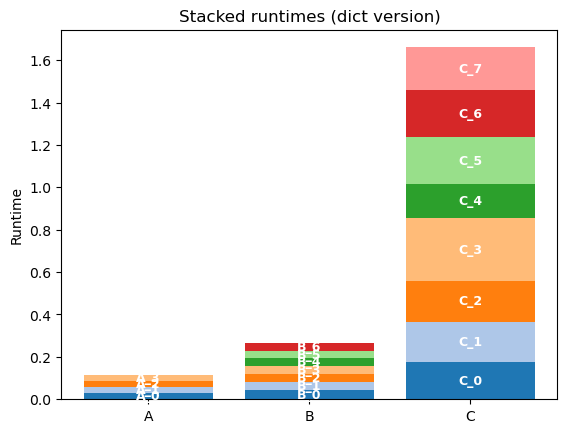

In [32]:
import matplotlib.pyplot as plt
import numpy as np

runtimes = {
    "A": runtimes_A,
    "B": runtimes_B,
    "C": runtimes_C
}

labels = list(runtimes.keys())
x = np.arange(len(labels))

colors = plt.cm.tab20.colors

for j, (label, values) in enumerate(runtimes.items()):
    bottom = 0
    for i, value in enumerate(values):
        bar = plt.bar(
            x[j],
            value,
            bottom=bottom,
            color=colors[i % len(colors)]
        )
        plt.text(
            x[j],
            bottom + value / 2,
            f"{label}_{i}",
            ha="center",
            va="center",
            color="white",
            fontsize=9,
            fontweight="bold"
        )
        bottom += value

plt.xticks(x, labels)
plt.ylabel("Runtime")
plt.title("Runtimes")
plt.show()